# TRỰC QUAN HÓA DỮ LIỆU REVIEW TIKI 9K ĐÃ GÁN NHÃN

Notebook được xây dựng theo cấu trúc của `Truc_quan_du_lieu.ipynb`.
Các biểu đồ tập trung vào quan hệ giữa nhãn `help` và:

- Rating.
- Độ dài review context.
- Helpful count của nền tảng.
- Trạng thái purchased.
- Thời gian tạo review.

## Bước 1: Chuẩn bị dữ liệu và feature

In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

%matplotlib inline
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11
pd.set_option("display.max_colwidth", 160)

DATA_PATH = Path("Data/gold_data/tiki_reviews_full_labeled_9k.csv")
if not DATA_PATH.exists():
    matches = list(Path(".").rglob("tiki_reviews_full_labeled_9k.csv"))
    if not matches:
        raise FileNotFoundError("Không tìm thấy tiki_reviews_full_labeled_9k.csv")
    DATA_PATH = matches[0]

print("Dữ liệu:", DATA_PATH.resolve())

Dữ liệu: /Users/dphong2005/Desktop/Demo_DS/Data/gold_data/tiki_reviews_full_labeled_9k.csv


In [2]:
df = pd.read_csv(DATA_PATH)

available_columns = [
    "review_id", "product_id", "user_id", "rating", "title", "content",
    "created_at", "helpful_count", "purchased", "crawled_at", "help"
]
missing = [col for col in available_columns if col not in df.columns]
if missing:
    raise ValueError(f"Thiếu cột cần thiết: {missing}")

df = df[available_columns].copy()
df["title"] = df["title"].fillna("").astype(str).str.strip()
df["content"] = df["content"].fillna("").astype(str).str.strip()
df["review_context"] = (
    df["title"] + ". " + df["content"]
).str.strip(". ")

df["created_at"] = pd.to_datetime(df["created_at"], errors="coerce")
df["crawled_at"] = pd.to_datetime(df["crawled_at"], errors="coerce")
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["helpful_count"] = pd.to_numeric(df["helpful_count"], errors="coerce").fillna(0)
df["help"] = pd.to_numeric(df["help"], errors="raise").astype(int)
df["purchased"] = df["purchased"].astype(bool)

# Feature engineering chỉ từ dữ liệu quan sát được.
df["review_char_length"] = df["review_context"].str.len()
df["review_word_length"] = df["review_context"].str.split().str.len()
df["title_char_length"] = df["title"].str.len()
df["content_char_length"] = df["content"].str.len()
df["sentence_count"] = df["review_context"].str.count(r"[.!?]+").clip(lower=1)
df["exclamation_count"] = df["review_context"].str.count("!")
df["question_count"] = df["review_context"].str.count(r"\?")
df["digit_count"] = df["review_context"].str.count(r"\d")
df["created_year"] = df["created_at"].dt.year
df["created_month"] = df["created_at"].dt.month
df["created_hour"] = df["created_at"].dt.hour
df["created_weekday"] = df["created_at"].dt.day_name()
df["has_helpful_vote"] = (df["helpful_count"] > 0).astype(int)

print(f"Kích thước sau khi tạo feature: {df.shape[0]:,} dòng x {df.shape[1]} cột")
display(df.head())

Kích thước sau khi tạo feature: 9,000 dòng x 25 cột


,review_id,product_id,user_id,rating,title,content,created_at,helpful_count,purchased,crawled_at,...,content_char_length,sentence_count,exclamation_count,question_count,digit_count,created_year,created_month,created_hour,created_weekday,has_helpful_vote
0,4839635,36626940,10852,5,Cực kì hài lòng,"Giao hàng nhanh chóng, sản phẩm đúng như quảng cáo. Đã sử dụng thử, khá tiện lợi!",2020-09-13 11:23:16,0,False,2026-05-05 22:48:50.033785,...,81,3,1,0,0,2020,9,11,Sunday,0
1,19814968,11183003,28493267,5,Cực kì hài lòng,Sp tốt. Rất hài lòng về cách phục vụ của shop,2024-03-21 09:18:54,0,False,2026-05-07 10:11:45.486510,...,45,2,0,0,0,2024,3,9,Thursday,0
2,12513167,59504295,6507390,5,Cực kì hài lòng,tot,2021-10-09 09:02:31,0,False,2026-05-06 17:14:07.192966,...,3,1,0,0,0,2021,10,9,Saturday,0
3,14825710,118137722,18115728,5,Cực kì hài lòng,Tuyệt vời ưng ý!,2022-02-07 08:16:39,0,False,2026-05-05 20:05:37.145608,...,16,2,1,0,0,2022,2,8,Monday,0
4,10951398,631034,18356094,5,Cực kì hài lòng,cực kỳ hài lòng sp,2021-07-07 08:33:48,0,False,2026-05-05 23:57:41.530019,...,18,1,0,0,0,2021,7,8,Wednesday,0


In [3]:
FIGURE_DIR = Path("EDA/figures_9k_labeled")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

def save_and_show(filename):
    path = FIGURE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

print("Thư mục figure:", FIGURE_DIR.resolve())

Thư mục figure: /Users/dphong2005/Desktop/Demo_DS/EDA/figures_9k_labeled


## Bước 2: Phân phối nhãn và rating

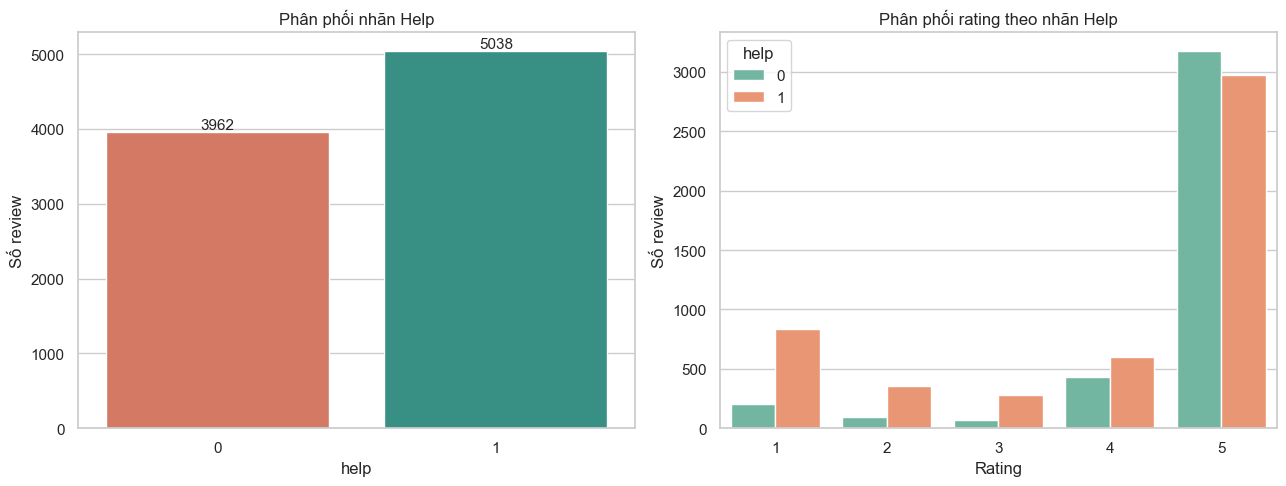

Saved: EDA/figures_9k_labeled/01_label_and_rating_distribution.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

label_counts = df["help"].value_counts().sort_index()
sns.barplot(
    x=label_counts.index, y=label_counts.values,
    hue=label_counts.index, palette={0: "#e76f51", 1: "#2a9d8f"},
    legend=False, ax=axes[0],
)
axes[0].set_title("Phân phối nhãn Help")
axes[0].set_xlabel("help")
axes[0].set_ylabel("Số review")
for container in axes[0].containers:
    axes[0].bar_label(container)

sns.countplot(data=df, x="rating", hue="help", palette="Set2", ax=axes[1])
axes[1].set_title("Phân phối rating theo nhãn Help")
axes[1].set_xlabel("Rating")
axes[1].set_ylabel("Số review")
axes[1].legend(title="help")
save_and_show("01_label_and_rating_distribution.png")

## Bước 3: Tỷ lệ helpful theo rating

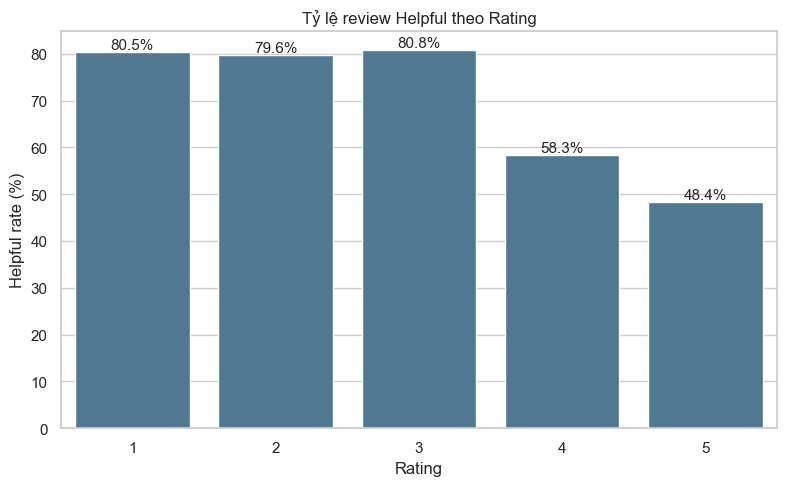

Saved: EDA/figures_9k_labeled/02_helpful_rate_by_rating.png


,rating,review_count,helpful_rate,helpful_rate_pct
0,1,1034,0.805,80.464
1,2,442,0.796,79.638
2,3,343,0.808,80.758
3,4,1033,0.583,58.277
4,5,6148,0.484,48.390


In [5]:
rating_effect = (
    df.groupby("rating")
    .agg(review_count=("review_id", "size"), helpful_rate=("help", "mean"))
    .reset_index()
)
rating_effect["helpful_rate_pct"] = rating_effect["helpful_rate"] * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(data=rating_effect, x="rating", y="helpful_rate_pct", color="#457b9d")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.title("Tỷ lệ review Helpful theo Rating")
plt.xlabel("Rating")
plt.ylabel("Helpful rate (%)")
save_and_show("02_helpful_rate_by_rating.png")
display(rating_effect.round(3))

## Bước 4: Độ dài review theo nhãn

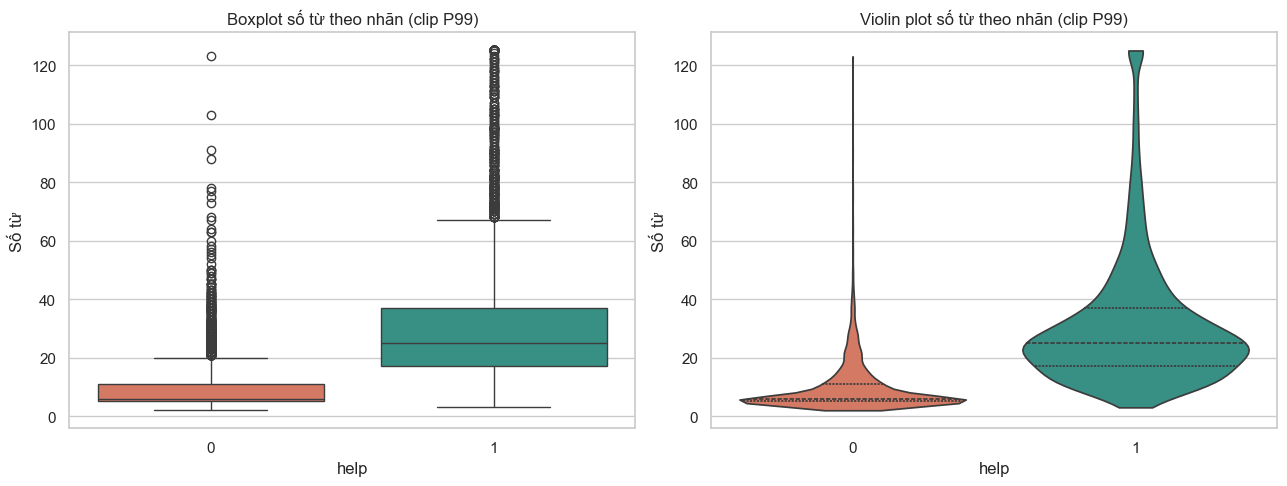

Saved: EDA/figures_9k_labeled/03_review_length_by_label.png


In [6]:
upper_word = df["review_word_length"].quantile(0.99)
plot_df = df.assign(
    word_length_99p=df["review_word_length"].clip(upper=upper_word)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(
    data=plot_df, x="help", y="word_length_99p",
    hue="help", palette={0: "#e76f51", 1: "#2a9d8f"},
    legend=False, ax=axes[0],
)
axes[0].set_title("Boxplot số từ theo nhãn (clip P99)")
axes[0].set_xlabel("help")
axes[0].set_ylabel("Số từ")

sns.violinplot(
    data=plot_df, x="help", y="word_length_99p",
    hue="help", palette={0: "#e76f51", 1: "#2a9d8f"},
    inner="quartile", legend=False, cut=0, ax=axes[1],
)
axes[1].set_title("Violin plot số từ theo nhãn (clip P99)")
axes[1].set_xlabel("help")
axes[1].set_ylabel("Số từ")
save_and_show("03_review_length_by_label.png")

## Bước 5: Ảnh hưởng của nhóm độ dài review

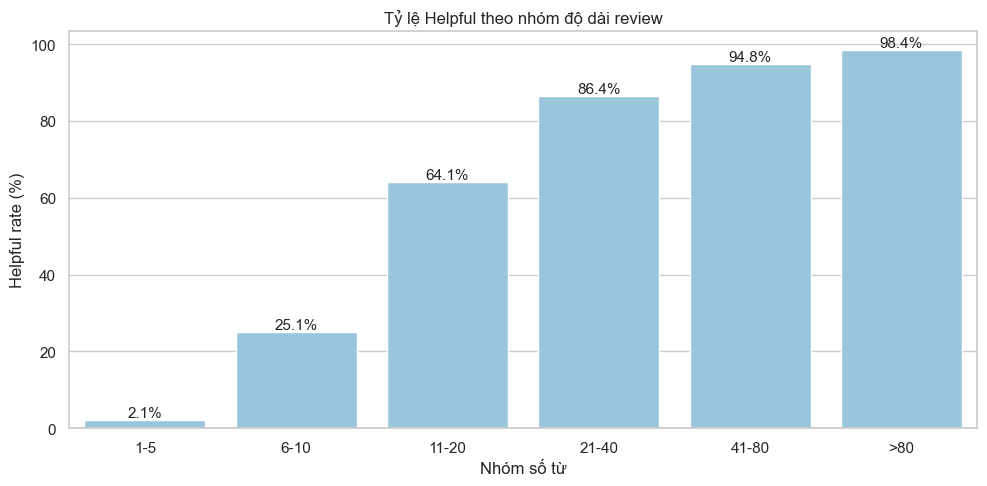

Saved: EDA/figures_9k_labeled/04_helpful_rate_by_length_group.png


,length_group,review_count,helpful_rate,helpful_rate_pct
0,1-5,1824,0.021,2.083
1,6-10,1424,0.251,25.140
2,11-20,1931,0.641,64.060
3,21-40,2696,0.864,86.387
4,41-80,871,0.948,94.834
5,>80,254,0.984,98.425


In [7]:
df["length_group"] = pd.cut(
    df["review_word_length"],
    bins=[-1, 5, 10, 20, 40, 80, np.inf],
    labels=["1-5", "6-10", "11-20", "21-40", "41-80", ">80"],
)
length_effect = (
    df.groupby("length_group", observed=False)
    .agg(review_count=("review_id", "size"), helpful_rate=("help", "mean"))
    .reset_index()
)
length_effect["helpful_rate_pct"] = length_effect["helpful_rate"] * 100

fig, ax1 = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=length_effect, x="length_group", y="helpful_rate_pct",
    color="#8ecae6", ax=ax1,
)
ax1.set_title("Tỷ lệ Helpful theo nhóm độ dài review")
ax1.set_xlabel("Nhóm số từ")
ax1.set_ylabel("Helpful rate (%)")
for container in ax1.containers:
    ax1.bar_label(container, fmt="%.1f%%")
save_and_show("04_helpful_rate_by_length_group.png")
display(length_effect.round(3))

## Bước 6: Rating, độ dài và nhãn Help

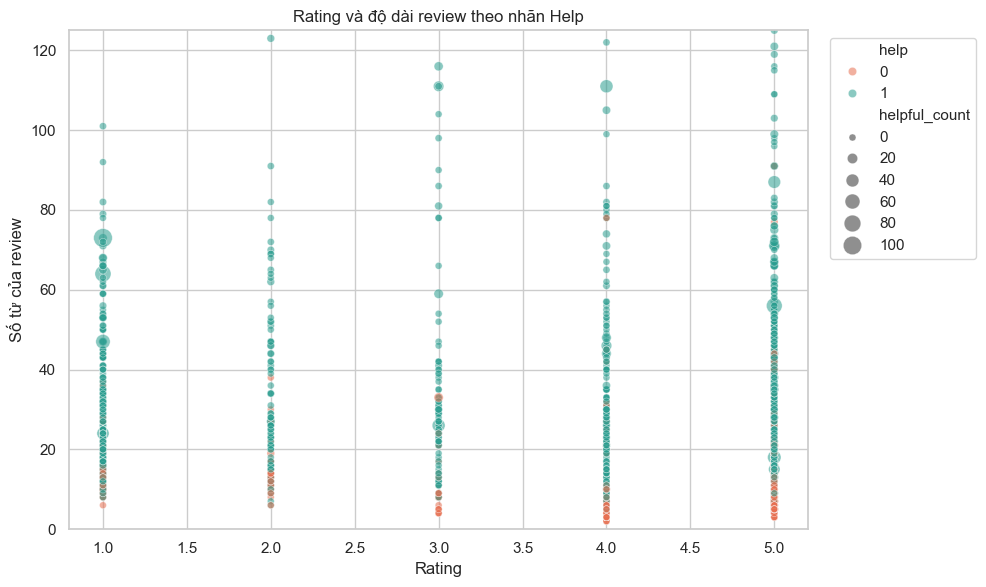

Saved: EDA/figures_9k_labeled/05_rating_length_scatter.png


In [8]:
sample = df.sample(min(3000, len(df)), random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=sample,
    x="rating",
    y="review_word_length",
    hue="help",
    size="helpful_count",
    sizes=(25, 180),
    alpha=0.55,
    palette={0: "#e76f51", 1: "#2a9d8f"},
)
plt.ylim(0, df["review_word_length"].quantile(0.99))
plt.title("Rating và độ dài review theo nhãn Help")
plt.xlabel("Rating")
plt.ylabel("Số từ của review")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
save_and_show("05_rating_length_scatter.png")

## Bước 7: Helpful count của nền tảng và nhãn gán

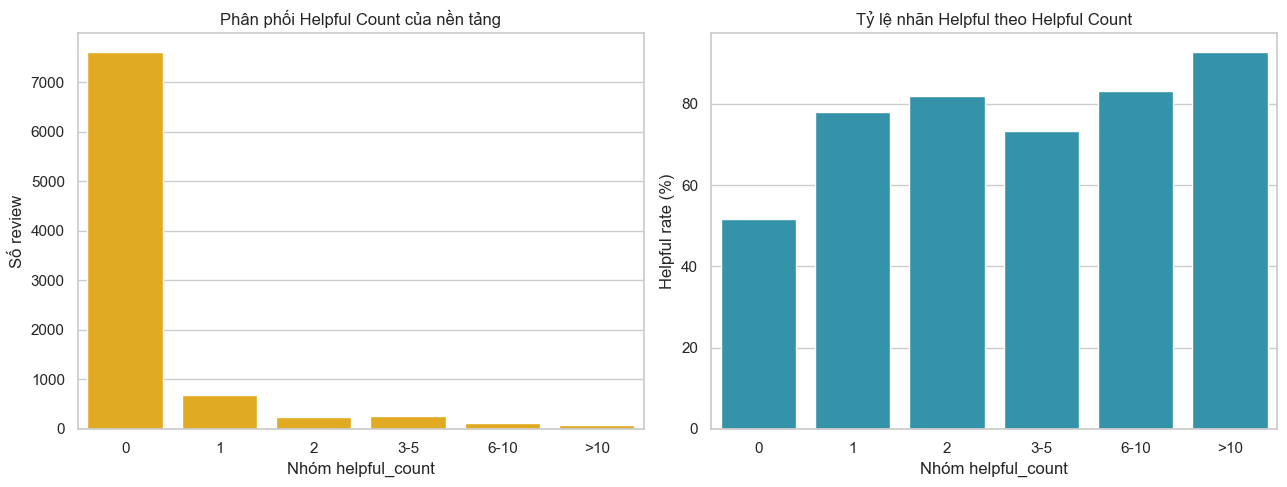

Saved: EDA/figures_9k_labeled/06_platform_helpful_count_analysis.png


,platform_vote_group,review_count,helpful_rate,helpful_rate_pct
0,0,7600,0.517,51.711
1,1,681,0.780,77.974
2,2,245,0.820,82.041
3,3-5,262,0.733,73.282
4,6-10,130,0.831,83.077
5,>10,82,0.927,92.683


In [9]:
vote_plot = df.assign(
    platform_vote_group=pd.cut(
        df["helpful_count"],
        bins=[-1, 0, 1, 2, 5, 10, np.inf],
        labels=["0", "1", "2", "3-5", "6-10", ">10"],
    )
)
vote_effect = (
    vote_plot.groupby("platform_vote_group", observed=False)
    .agg(review_count=("review_id", "size"), helpful_rate=("help", "mean"))
    .reset_index()
)
vote_effect["helpful_rate_pct"] = vote_effect["helpful_rate"] * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=vote_plot, x="platform_vote_group", color="#ffb703", ax=axes[0])
axes[0].set_title("Phân phối Helpful Count của nền tảng")
axes[0].set_xlabel("Nhóm helpful_count")
axes[0].set_ylabel("Số review")

sns.barplot(
    data=vote_effect, x="platform_vote_group", y="helpful_rate_pct",
    color="#219ebc", ax=axes[1],
)
axes[1].set_title("Tỷ lệ nhãn Helpful theo Helpful Count")
axes[1].set_xlabel("Nhóm helpful_count")
axes[1].set_ylabel("Helpful rate (%)")
save_and_show("06_platform_helpful_count_analysis.png")
display(vote_effect.round(3))

## Bước 8: Purchased và nhãn Help

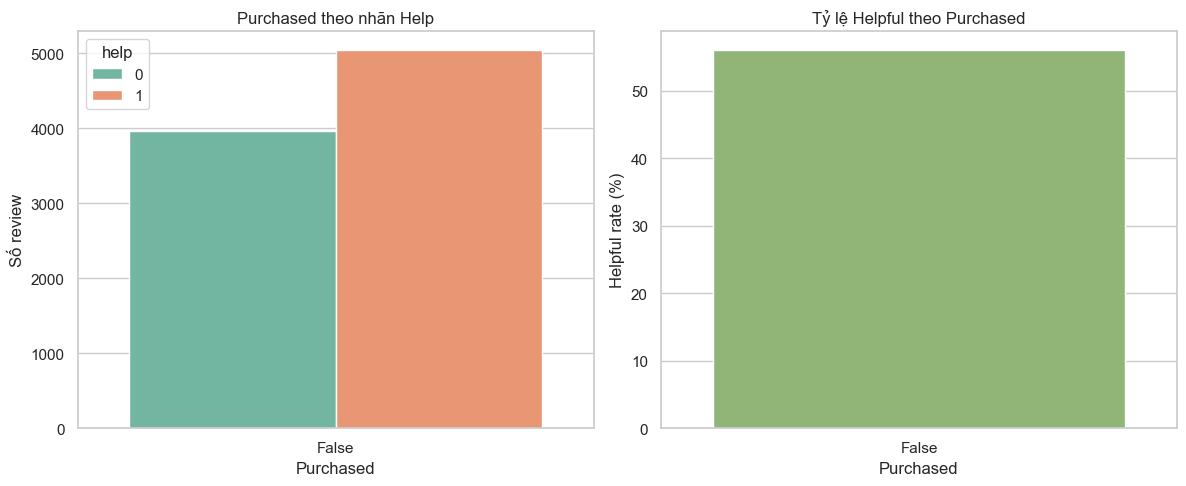

Saved: EDA/figures_9k_labeled/07_purchased_analysis.png


,purchased,review_count,helpful_rate,avg_word_length,helpful_rate_pct
0,False,9000,0.56,22.641,55.978


In [10]:
purchased_effect = (
    df.groupby("purchased")
    .agg(
        review_count=("review_id", "size"),
        helpful_rate=("help", "mean"),
        avg_word_length=("review_word_length", "mean"),
    )
    .reset_index()
)
purchased_effect["helpful_rate_pct"] = purchased_effect["helpful_rate"] * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(data=df, x="purchased", hue="help", palette="Set2", ax=axes[0])
axes[0].set_title("Purchased theo nhãn Help")
axes[0].set_xlabel("Purchased")
axes[0].set_ylabel("Số review")

sns.barplot(
    data=purchased_effect, x="purchased", y="helpful_rate_pct",
    color="#90be6d", ax=axes[1],
)
axes[1].set_title("Tỷ lệ Helpful theo Purchased")
axes[1].set_xlabel("Purchased")
axes[1].set_ylabel("Helpful rate (%)")
save_and_show("07_purchased_analysis.png")
display(purchased_effect.round(3))

## Bước 9: Xu hướng theo thời gian

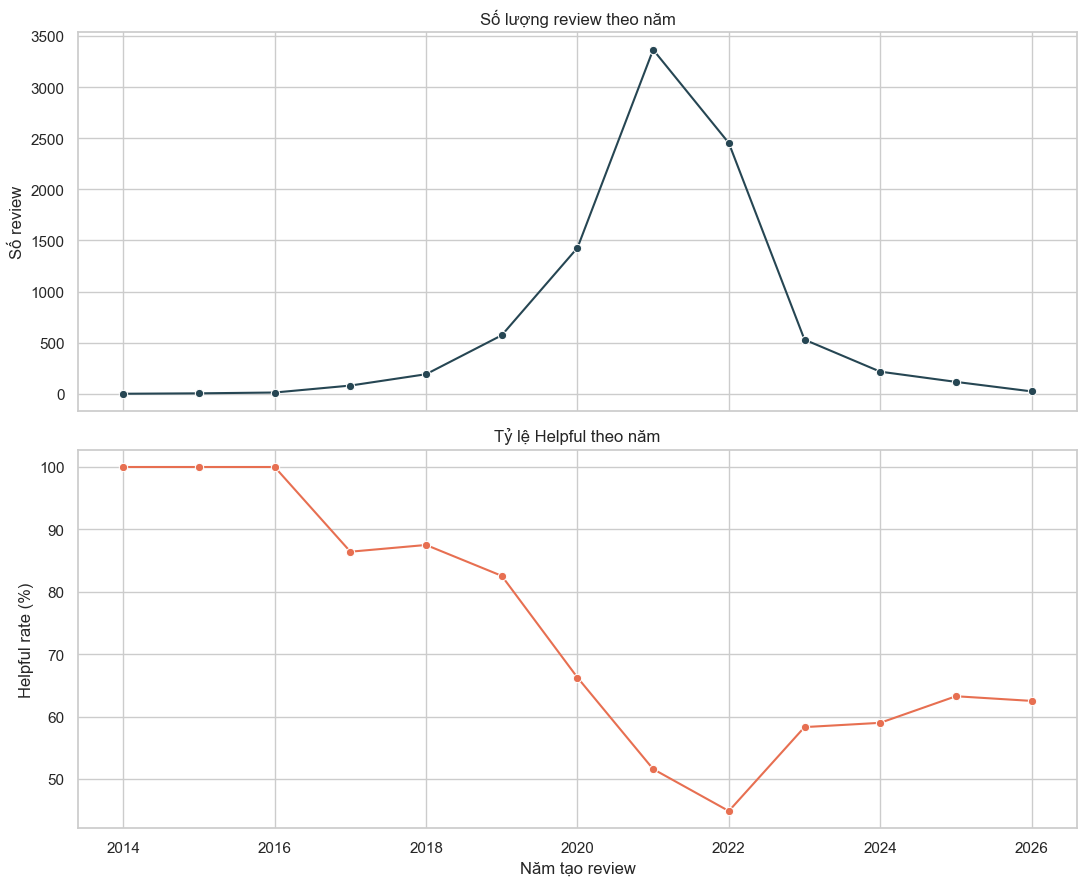

Saved: EDA/figures_9k_labeled/08_time_trend.png


,created_year,review_count,helpful_rate,avg_word_length,helpful_rate_pct
0,2014,1,1.000,69.000,100.000
1,2015,5,1.000,105.000,100.000
2,2016,13,1.000,106.923,100.000
3,2017,81,0.864,48.914,86.420
4,2018,192,0.875,42.214,87.500
5,2019,573,0.825,38.763,82.548
6,2020,1428,0.662,28.008,66.246
7,2021,3366,0.516,19.414,51.575
8,2022,2453,0.448,16.784,44.843
9,2023,530,0.583,23.389,58.302


In [11]:
time_effect = (
    df.dropna(subset=["created_year"])
    .groupby("created_year")
    .agg(
        review_count=("review_id", "size"),
        helpful_rate=("help", "mean"),
        avg_word_length=("review_word_length", "mean"),
    )
    .reset_index()
)
time_effect["helpful_rate_pct"] = time_effect["helpful_rate"] * 100

fig, axes = plt.subplots(2, 1, figsize=(11, 9), sharex=True)
sns.lineplot(
    data=time_effect, x="created_year", y="review_count",
    marker="o", color="#264653", ax=axes[0],
)
axes[0].set_title("Số lượng review theo năm")
axes[0].set_ylabel("Số review")

sns.lineplot(
    data=time_effect, x="created_year", y="helpful_rate_pct",
    marker="o", color="#e76f51", ax=axes[1],
)
axes[1].set_title("Tỷ lệ Helpful theo năm")
axes[1].set_xlabel("Năm tạo review")
axes[1].set_ylabel("Helpful rate (%)")
save_and_show("08_time_trend.png")
display(time_effect.round(3))

## Bước 10: Heatmap tương quan

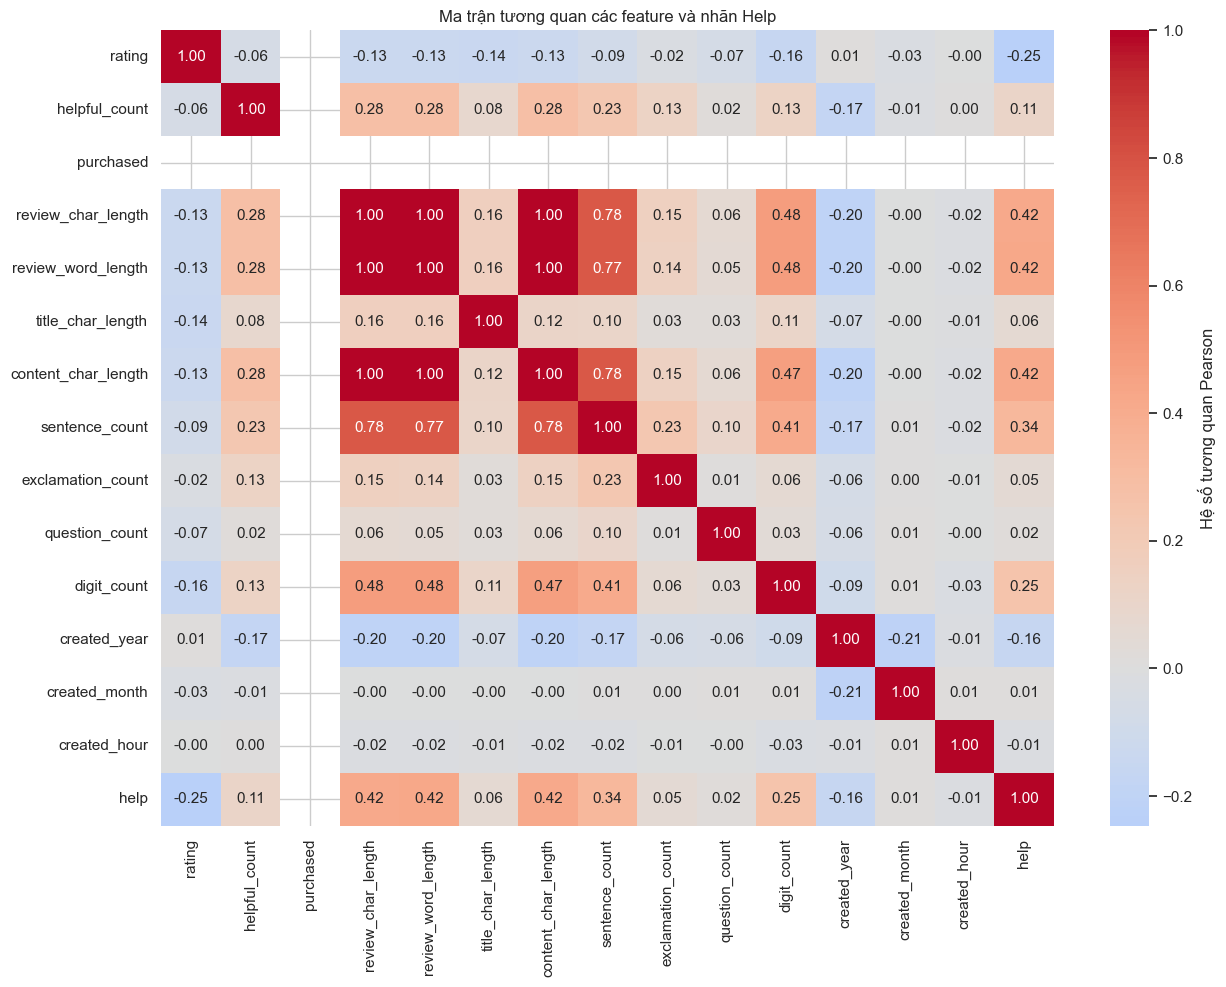

Saved: EDA/figures_9k_labeled/09_correlation_heatmap.png


In [12]:
corr_columns = [
    "rating", "helpful_count", "purchased", "review_char_length",
    "review_word_length", "title_char_length", "content_char_length",
    "sentence_count", "exclamation_count", "question_count",
    "digit_count", "created_year", "created_month", "created_hour", "help",
]
corr = df[corr_columns].astype(float).corr()

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=False,
    cbar_kws={"label": "Hệ số tương quan Pearson"},
)
plt.title("Ma trận tương quan các feature và nhãn Help")
save_and_show("09_correlation_heatmap.png")

## Bước 11: FacetGrid độ dài review theo rating và nhãn

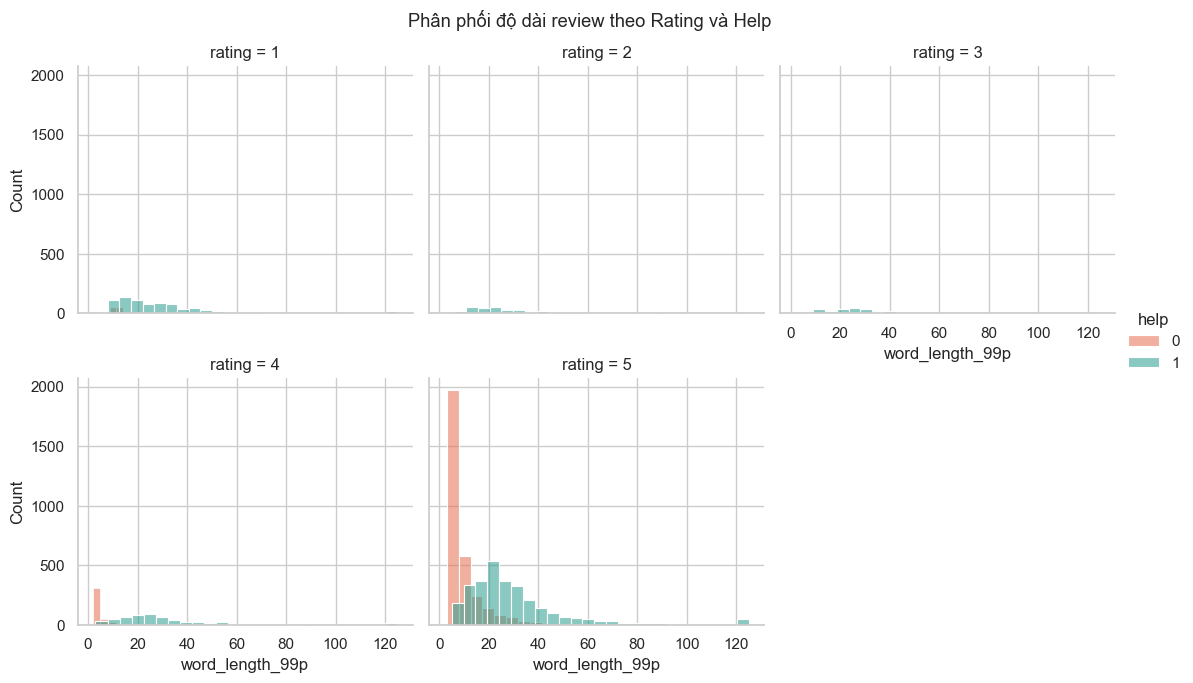

Saved: EDA/figures_9k_labeled/10_length_facet_by_rating.png


In [13]:
facet_df = df[df["rating"].isin([1, 2, 3, 4, 5])].copy()
facet_df["word_length_99p"] = facet_df["review_word_length"].clip(
    upper=facet_df["review_word_length"].quantile(0.99)
)
g = sns.FacetGrid(
    facet_df,
    col="rating",
    hue="help",
    col_wrap=3,
    height=3.3,
    aspect=1.15,
    palette={0: "#e76f51", 1: "#2a9d8f"},
)
g.map(sns.histplot, "word_length_99p", bins=25, alpha=0.55)
g.add_legend(title="help")
g.fig.suptitle("Phân phối độ dài review theo Rating và Help", y=1.03)
g.savefig(FIGURE_DIR / "10_length_facet_by_rating.png", dpi=160, bbox_inches="tight")
plt.show()
print("Saved:", FIGURE_DIR / "10_length_facet_by_rating.png")

## Bước 12: Word Cloud của nội dung review theo nhãn Help

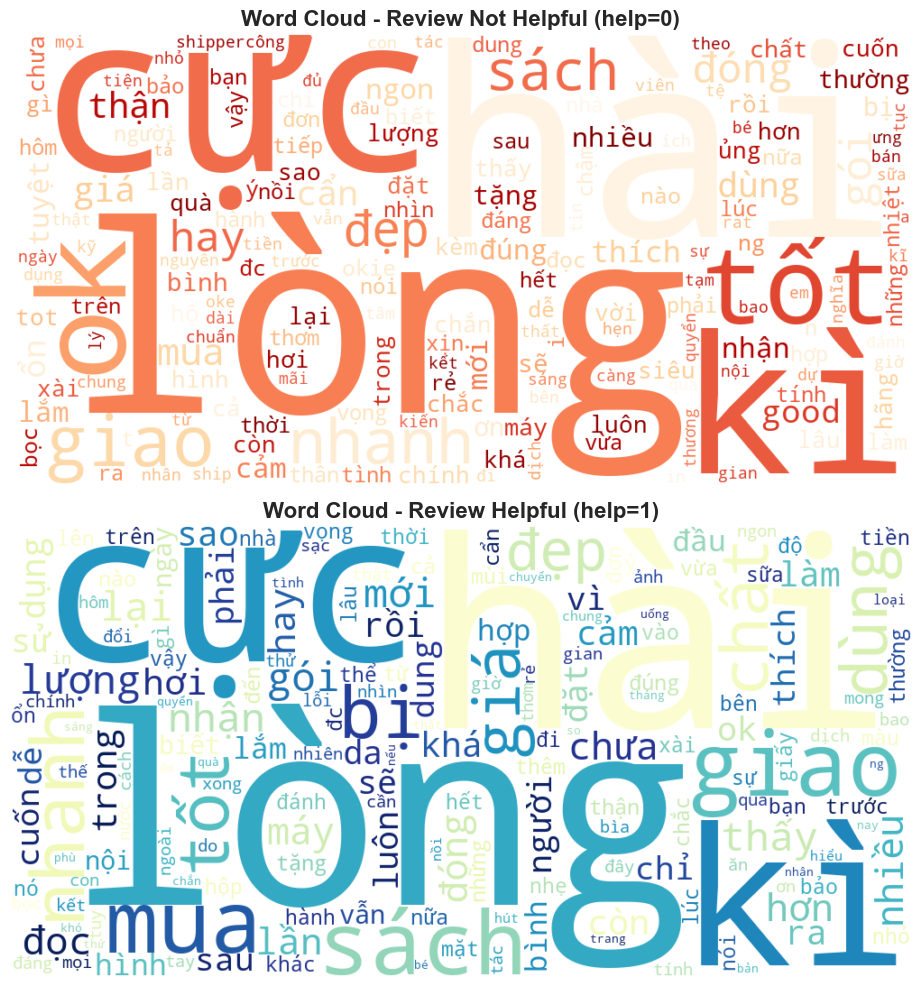

Saved: EDA/figures_9k_labeled/11_wordcloud_by_help_label.png


In [14]:
# Word Cloud giúp quan sát nhanh các từ xuất hiện thường xuyên trong review.
# Tách riêng help=0 và help=1 để so sánh nội dung giữa hai nhóm.
try:
    from wordcloud import WordCloud
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wordcloud"])
    from wordcloud import WordCloud

VIETNAMESE_STOPWORDS = {
    "và", "là", "của", "có", "cho", "được", "mình", "tôi", "thì", "mà",
    "rất", "quá", "này", "đó", "với", "khi", "đã", "cũng", "không", "ko",
    "k", "nhưng", "nên", "ở", "về", "một", "như", "cái", "các", "để",
    "sản", "phẩm", "sp", "shop", "tiki", "hàng", "ạ", "nha", "nhé",
}

def prepare_wordcloud_text(series):
    text = " ".join(series.fillna("").astype(str)).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"[^0-9a-zA-ZÀ-ỹ\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

wordcloud_config = {
    "width": 1000,
    "height": 500,
    "background_color": "white",
    "max_words": 180,
    "collocations": False,
    "stopwords": VIETNAMESE_STOPWORDS,
    "random_state": 42,
}

text_not_helpful = prepare_wordcloud_text(df.loc[df["help"] == 0, "review_context"])
text_helpful = prepare_wordcloud_text(df.loc[df["help"] == 1, "review_context"])

wc_not_helpful = WordCloud(
    colormap="OrRd",
    **wordcloud_config,
).generate(text_not_helpful)

wc_helpful = WordCloud(
    colormap="YlGnBu",
    **wordcloud_config,
).generate(text_helpful)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
axes[0].imshow(wc_not_helpful, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title(
    "Word Cloud - Review Not Helpful (help=0)",
    fontsize=16,
    fontweight="bold",
)

axes[1].imshow(wc_helpful, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title(
    "Word Cloud - Review Helpful (help=1)",
    fontsize=16,
    fontweight="bold",
)

save_and_show("11_wordcloud_by_help_label.png")

## Kết luận trực quan

- Review được gán `help=1` có xu hướng dài và giàu thông tin hơn, nhưng độ dài không đủ để quyết định nhãn.
- Rating thấp có thể vẫn hữu ích nếu review mô tả lỗi hoặc trải nghiệm cụ thể.
- Helpful count của nền tảng có liên hệ với nhãn nhưng không hoàn toàn tương đương nhãn LLM.
- Các biểu đồ thời gian phản ánh phân bố mẫu thu thập, không chứng minh quan hệ nhân quả.
- Word Cloud chỉ phản ánh tần suất xuất hiện của từ, không đo trực tiếp mức độ quan trọng
  hoặc quan hệ nhân quả giữa từ và nhãn.